# Which Model Predicts Price Best? The Honest Answer

"Which model is best" is the wrong question. On daily crypto the
honest one is: whose apparent edge **survives** purged
cross-validation and a Deflated Sharpe Ratio that corrects for
having tried several models at all. The spoiler, as usual on real
price data, is that almost nothing survives — and that is the
answer, not a failure.

Same real BTC/USDT daily candles as `ohlc_trading_signal.ipynb`,
fetched with `pricehub` (cached, offline after first run). Two steps:

1. Naive shuffled k-fold vs `PurgedKFold` R² per model — the leak
   gap, model by model.
2. `CombinatorialPurgedCV` → a toy long/short strategy → per-path
   Sharpe → Deflated Sharpe with `n_trials` = number of models, so
   the score is corrected for the search itself.

This is a methodology demonstration, not a tradeable strategy.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from pricehub import get_ohlc
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor, RandomForestRegressor
from sklearn.exceptions import FitFailedWarning
from sklearn.linear_model import Ridge
from sklearn.model_selection import KFold, cross_val_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

from purgedcv import (
    CombinatorialPurgedCV,
    PurgedKFold,
    deflated_sharpe_ratio,
    probabilistic_sharpe_ratio,
)

INTERVAL = "1d"  # any pricehub interval; bar duration is inferred from data
SEED = 0
H = 20  # forward-return horizon, in bars
N_SPLITS = 5

## Real OHLC via pricehub (cached, shared with the other notebook)

`pricehub` pulls Binance spot BTC/USDT daily bars over a pinned
window (2021-01-01 to 2023-09-28) for reproducibility, cached to the
same CSV as `ohlc_trading_signal.ipynb`. Publicly available market
data; subject to the exchange's API terms. Set `INTERVAL` for any timeframe.

In [2]:
DATA_DIR = Path("data") if Path("data").exists() else Path("examples/data")
DATA_DIR.mkdir(parents=True, exist_ok=True)
cache = DATA_DIR / f"btcusdt_{INTERVAL}_binance_spot_2021_2023.csv"

if cache.exists():
    print(f"Using cached: {cache}")
    raw = pd.read_csv(cache, index_col=0, parse_dates=True)
else:
    print("Fetching via pricehub (binance_spot, BTCUSDT, 1d) ...")
    raw = get_ohlc(
        broker="binance_spot",
        symbol="BTCUSDT",
        interval=INTERVAL,
        start="2021-01-01",
        end="2023-09-28",
    )
    raw.to_csv(cache)

ohlc = raw[["Open", "High", "Low", "Close", "Volume"]].rename(
    columns={"Open": "open", "High": "high", "Low": "low", "Close": "close", "Volume": "volume"}
)
ohlc.index = pd.to_datetime(ohlc.index)
BAR = ohlc.index.to_series().diff().median()  # one bar's duration
print(f"{len(ohlc)} bars, {ohlc.index[0].date()} to {ohlc.index[-1].date()}")

Using cached: data/btcusdt_1d_binance_spot_2021_2023.csv
1001 bars, 2021-01-01 to 2023-09-28


## Features and forward-return label

Plausible, commonly used features: 5- and 20-bar momentum, 20-bar
realised volatility, and a volume z-score. None has a robust reason
to forecast crypto returns — that is the point. The label is the log
return over the next `H` bars, so neighbouring labels overlap.

In [3]:
logp = np.log(ohlc["close"].to_numpy())
vol = ohlc["volume"].to_numpy()

mom_5 = pd.Series(logp).diff(5).to_numpy()
mom_20 = pd.Series(logp).diff(20).to_numpy()
ret_1 = pd.Series(logp).diff(1)
rvol_20 = ret_1.rolling(20).std().to_numpy()
vol_z = (
    (pd.Series(vol) - pd.Series(vol).rolling(20).mean()) / pd.Series(vol).rolling(20).std()
).to_numpy()

feat = np.column_stack([mom_5, mom_20, rvol_20, vol_z])
fwd = np.empty(len(logp))
fwd[:] = np.nan
fwd[: len(logp) - H] = logp[H:] - logp[: len(logp) - H]  # next-H-bar return

ok = np.isfinite(feat).all(axis=1) & np.isfinite(fwd)
X = feat[ok]
y = fwd[ok]
pred = pd.Series(ohlc.index.to_numpy()[ok])
evalu = pred + H * BAR
print(f"usable rows: {len(y)}  features: {X.shape[1]}")

usable rows: 961  features: 4


## Step 1 — naive shuffled k-fold vs PurgedKFold (R²)

Every model is wrapped in a scaler. The gap between the two columns
is leakage, not skill.

In [4]:
models = {
    "mean (baseline)": DummyRegressor(strategy="mean"),
    "Ridge": make_pipeline(StandardScaler(), Ridge(alpha=1.0)),
    "k-NN": make_pipeline(StandardScaler(), KNeighborsRegressor(n_neighbors=15)),
    "RandomForest": RandomForestRegressor(n_estimators=200, random_state=SEED),
    "HistGBR": HistGradientBoostingRegressor(random_state=SEED),
}

naive = KFold(n_splits=N_SPLITS, shuffle=True, random_state=SEED)
purged = PurgedKFold(
    n_splits=N_SPLITS,
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=H * BAR,
    embargo=H * BAR,
)

rows = []
for name, model in models.items():
    n_r2 = float(cross_val_score(model, X, y, cv=naive, scoring="r2").mean())
    p_r2 = float(cross_val_score(model, X, y, cv=purged, scoring="r2").mean())
    rows.append({"model": name, "naive_R2": n_r2, "purged_R2": p_r2})

r2_table = pd.DataFrame(rows).set_index("model").round(3)
r2_table

,naive_R2,purged_R2
model,,
mean (baseline),-0.018,-0.093
Ridge,-0.006,-0.155
k-NN,0.017,-0.433
RandomForest,0.174,-0.669
HistGBR,0.065,-0.712


## Step 2 — does any edge survive CPCV + Deflated Sharpe?

For each model: `CombinatorialPurgedCV` builds independent
out-of-sample paths; a toy strategy goes long when the predicted
forward return is positive, short otherwise; we score the per-bar
strategy return on each path.

The honest number is the **Deflated Sharpe Ratio**. `n_trials` is
the number of candidate models, and `var_sharpe` is the spread of
their Sharpe estimates — so a model is only credited if it beats
what the *best of several tries* would produce by chance. DSR ≥ 0.95
means the edge survives that correction.

In [5]:
cpcv = CombinatorialPurgedCV(
    n_splits=6,
    n_test_groups=2,
    prediction_times=pred,
    evaluation_times=evalu,
    purge_horizon=H * BAR,
    embargo=H * BAR,
)
candidates = {k: v for k, v in models.items() if k != "mean (baseline)"}


def strategy_returns_per_path(estimator):
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", FitFailedWarning)
        paths = cpcv.backtest_paths(estimator, X, y)
    out = []
    for path in paths:
        m = np.isfinite(path)
        if m.sum() < 30:
            continue
        pnl = np.sign(path[m]) * y[m]  # long if predicted up, else short
        if pnl.std() > 0:
            out.append(pnl)
    return out


def sharpe(r):
    return float(np.mean(r) / np.std(r)) if np.std(r) > 0 else 0.0


per_model = {name: strategy_returns_per_path(est) for name, est in candidates.items()}
model_sharpe = {
    name: float(np.mean([sharpe(r) for r in paths])) if paths else 0.0
    for name, paths in per_model.items()
}
var_sharpe = float(np.var(list(model_sharpe.values())))
n_trials = len(candidates)
print(f"var_sharpe across {n_trials} models = {var_sharpe:.5f}")

var_sharpe across 4 models = 0.00059


In [6]:
result = []
for name, paths in per_model.items():
    if not paths:
        result.append({"model": name, "mean_PSR": np.nan, "DSR": np.nan})
        continue
    pooled = np.concatenate(paths)
    psr = float(np.mean([probabilistic_sharpe_ratio(r, benchmark_skill=0.0) for r in paths]))
    dsr = deflated_sharpe_ratio(pooled, n_trials=n_trials, var_sharpe=var_sharpe)
    result.append({"model": name, "mean_PSR": round(psr, 3), "DSR": round(dsr, 3)})

survive = pd.DataFrame(result).set_index("model")
survive["survives_DSR>=0.95"] = survive["DSR"] >= 0.95
summary = r2_table.join(survive)
summary

,naive_R2,purged_R2,mean_PSR,DSR,survives_DSR>=0.95
model,,,,,
mean (baseline),-0.018,-0.093,NaN,NaN,NaN
Ridge,-0.006,-0.155,0.179,0.000,False
k-NN,0.017,-0.433,0.331,0.002,False
RandomForest,0.174,-0.669,0.385,0.007,False
HistGBR,0.065,-0.712,0.268,0.001,False


## The verdict, in one chart

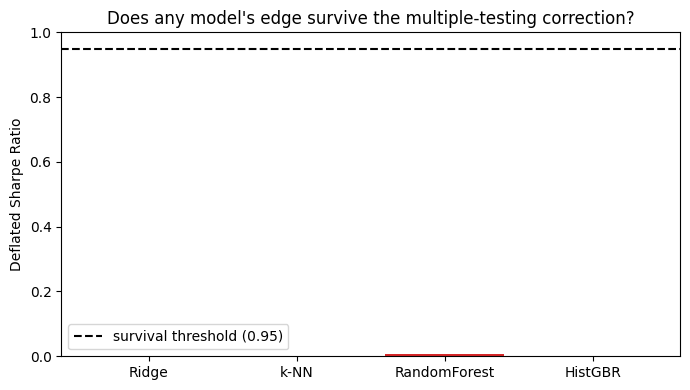

In [7]:
fig, ax = plt.subplots(figsize=(7, 4))
names = list(per_model)
dsr_vals = [summary.loc[n, "DSR"] for n in names]
colors = ["#2ca02c" if v >= 0.95 else "#d62728" for v in dsr_vals]
ax.bar(names, dsr_vals, color=colors)
ax.axhline(0.95, color="black", linestyle="--", label="survival threshold (0.95)")
ax.set_ylabel("Deflated Sharpe Ratio")
ax.set_title("Does any model's edge survive the multiple-testing correction?")
ax.set_ylim(0, 1)
ax.legend()
plt.tight_layout()
plt.show()

## Verdict

Read the table top to bottom. Naive shuffled k-fold hands several
models a flattering R²; `PurgedKFold` removes the label overlap and
those numbers collapse. Then the Deflated Sharpe Ratio asks the only
question that pays rent: after correcting for the fact that we tried
several models, does any edge clear 0.95? On real BTC daily bars
with ordinary features, it does not.

That is the right answer, not a disappointing one. The best model
here is the knowledge that there is no edge — bought for the price
of an honest cross-validation instead of a blown account. Swap in
your own features and labels; the harness stays the same, and so
does the discipline.

**Data:** Binance spot BTC/USDT 1-day candles via the `pricehub`
package, pinned window 2021-01-01 to 2023-09-28. Publicly available
market data; subject to the exchange's API terms.